# AP M2 — EfficientNetV2-S com manifests oficiais — sem Focal Loss

Notebook corrigido para usar diretamente os splits já existentes em `MIQR-CC-Dataset-splits`:

- `train_manifest.csv`
- `val_manifest.csv`
- `test_manifest.csv`

Assim, o notebook **não volta a fazer split** e mantém exatamente a mesma divisão de dados usada nas restantes experiências.

A loss usada é `CrossEntropyLoss` ponderada, sem Focal Loss.


In [1]:
# =========================
# 1. Imports e configuração
# =========================

import os
import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

# Evita alguma fragmentação de memória CUDA
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [2]:
# =========================
# 2. Configuração principal
# =========================

DATA_ROOT = Path('/mounts/mecd-ap-g5/data')
DATASET_DIR = DATA_ROOT / 'MIQR-CC-Dataset'
PROCESSED_IMAGES_DIR = DATASET_DIR / 'processed'
SPLITS_DIR = DATA_ROOT / 'MIQR-CC-Dataset-splits'

TRAIN_MANIFEST = SPLITS_DIR / 'train_manifest.csv'
VAL_MANIFEST   = SPLITS_DIR / 'val_manifest.csv'
TEST_MANIFEST  = SPLITS_DIR / 'test_manifest.csv'

NOTEBOOK_NAME = 'efficientnetv2s_manifest_splits_crossentropy_no_focal'
RESULTS_DIR = Path('/mounts/mecd-ap-g5/results') / NOTEBOOK_NAME
MODELS_DIR = Path('/mounts/mecd-ap-g5/models') / NOTEBOOK_NAME
FIGURES_DIR = RESULTS_DIR / 'figures'
CSV_DIR = RESULTS_DIR / 'csv'

for d in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR, CSV_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Hiperparâmetros
IMG_SIZE = 224

# Se der CUDA out of memory, baixa BATCH_SIZE para 4, 2 ou 1.
BATCH_SIZE = 8
ACCUMULATION_STEPS = 2

NUM_WORKERS = 4
PIN_MEMORY = torch.cuda.is_available()

EPOCHS_HEAD = 8
EPOCHS_FINETUNE = 20
PATIENCE = 6

LR_HEAD = 3e-4
LR_BACKBONE = 1e-5
WEIGHT_DECAY = 1e-4

BASELINE_MACRO_F1 = 0.738

NUM_CLASSES = 4

print('Dataset:', DATASET_DIR)
print('Processed images:', PROCESSED_IMAGES_DIR)
print('Splits:', SPLITS_DIR)
print('Train manifest:', TRAIN_MANIFEST)
print('Val manifest:', VAL_MANIFEST)
print('Test manifest:', TEST_MANIFEST)
print('Results:', RESULTS_DIR)
print('Models:', MODELS_DIR)


Dataset: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset
Processed images: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset/processed
Splits: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset-splits
Train manifest: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset-splits/train_manifest.csv
Val manifest: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset-splits/val_manifest.csv
Test manifest: /mounts/mecd-ap-g5/data/MIQR-CC-Dataset-splits/test_manifest.csv
Results: /mounts/mecd-ap-g5/results/efficientnetv2s_manifest_splits_crossentropy_no_focal
Models: /mounts/mecd-ap-g5/models/efficientnetv2s_manifest_splits_crossentropy_no_focal


In [3]:
# =========================
# 3. Carregar manifests oficiais dos splits
# =========================

for path in [TRAIN_MANIFEST, VAL_MANIFEST, TEST_MANIFEST]:
    assert path.exists(), f"Manifest não encontrado: {path}"

assert DATASET_DIR.exists(), f"DATASET_DIR não existe: {DATASET_DIR}"
assert SPLITS_DIR.exists(), f"SPLITS_DIR não existe: {SPLITS_DIR}"

train_df = pd.read_csv(TRAIN_MANIFEST)
val_df   = pd.read_csv(VAL_MANIFEST)
test_df  = pd.read_csv(TEST_MANIFEST)

print('Train:', train_df.shape)
print('Val:', val_df.shape)
print('Test:', test_df.shape)

print('\nColunas train_manifest:')
print(train_df.columns.tolist())

display(train_df.head())


Train: (1067, 6)
Val: (234, 6)
Test: (267, 6)

Colunas train_manifest:
['patient_id', 'Label', 'final_label', 'image_type', 'image_path', 'split']


,patient_id,Label,final_label,image_type,image_path,split
0,5,Malignant Stricture,Stricture,S,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,train
1,16,Malignant Stricture,Stricture,S,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,train
2,16,Malignant Stricture,Stricture,S,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,train
3,16,Malignant Stricture,Stricture,S,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,train
4,16,Malignant Stricture,Stricture,S,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,train


In [4]:
# =========================
# 4. Normalizar labels e preparar targets
# =========================

# Mantemos nomes consistentes para todo o notebook.
class_names = ["Biliary Leaks", "Lithiasis", "Stricture", "Normal"]
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

def map_to_4_classes(label):
    """Mapeia variações de labels para as 4 classes principais."""
    if pd.isna(label):
        return None

    label = str(label).strip()
    key = label.lower().replace('_', ' ').replace('-', ' ')
    key = ' '.join(key.split())

    if key in {'', 'nan', 'none', 'unlabelled', 'unlabeled'}:
        return None

    if key in {'biliary leaks', 'biliary leak', 'bile leaks', 'bile leak'}:
        return 'Biliary Leaks'

    if key in {'lithiasis', 'biliary lithiasis', 'stones', 'stone'}:
        return 'Lithiasis'

    if key in {'normal', 'normals'}:
        return 'Normal'

    if 'stricture' in key:
        return 'Stricture'

    return None


def find_label_column(df):
    candidates = ['label', 'Label', 'final_label', 'class', 'class_name', 'diagnosis', 'target_name']
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(f"Não encontrei coluna de label. Colunas disponíveis: {df.columns.tolist()}")


def prepare_labels(split_df, split_name):
    split_df = split_df.copy()

    # Se existir uma coluna target numérica mas também existir label textual, preferimos normalizar o label textual.
    label_col = find_label_column(split_df)
    split_df['label'] = split_df[label_col].apply(map_to_4_classes)

    invalid = split_df['label'].isna().sum()
    if invalid > 0:
        print(f"[{split_name}] A remover {invalid} linhas com labels inválidas.")
        display(split_df[split_df['label'].isna()].head())
        split_df = split_df[split_df['label'].notna()].copy()

    split_df['label_idx'] = split_df['label'].map(class_to_idx).astype(int)

    if 'patient_id' in split_df.columns:
        split_df['patient_id'] = split_df['patient_id'].astype(str)

    return split_df

train_df = prepare_labels(train_df, 'train')
val_df   = prepare_labels(val_df, 'val')
test_df  = prepare_labels(test_df, 'test')

print('Distribuição de classes por split:')
for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'\n{name.upper()} — {len(split_df)} imagens')
    display(split_df['label'].value_counts().reindex(class_names, fill_value=0))


Distribuição de classes por split:

TRAIN — 1067 imagens


label
Biliary Leaks    110
Lithiasis        505
Stricture        255
Normal           197
Name: count, dtype: int64


VAL — 234 imagens


label
Biliary Leaks    24
Lithiasis        98
Stricture        53
Normal           59
Name: count, dtype: int64


TEST — 267 imagens


label
Biliary Leaks     17
Lithiasis        123
Stricture         84
Normal            43
Name: count, dtype: int64

In [5]:
# =========================
# 5. Resolver caminhos das imagens a partir dos manifests
# =========================

# Os manifests podem ter nomes de colunas diferentes consoante a versão.
# Esta função procura automaticamente a coluna de caminho mais provável.
def find_path_column(df):
    candidates = [
        'image_path',
        'path',
        'filepath',
        'file_path',
        'filename',
        'file',
        'processed_image_path',
        'raw_image_path',
    ]
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(f"Não encontrei coluna de caminho da imagem. Colunas disponíveis: {df.columns.tolist()}")

PATH_COL = find_path_column(train_df)
print('Coluna de caminho usada:', PATH_COL)


def resolve_image_path(x, split_name):
    """Resolve caminhos absolutos ou relativos guardados no manifest."""
    x = str(x).strip()
    p = Path(x)

    candidates = []

    # 1) Caminho absoluto ou relativo ao diretório atual
    candidates.append(p)

    # 2) Relativo ao dataset original
    candidates.append(DATASET_DIR / x)

    # 3) Relativo à pasta de splits
    candidates.append(SPLITS_DIR / x)

    # 4) Relativo à subpasta do split: train/val/test
    candidates.append(SPLITS_DIR / split_name / x)

    # 5) Se o manifest tiver apenas processed/ficheiro.png ou raw/ficheiro.png
    candidates.append(DATASET_DIR / x)

    # 6) Pelo nome do ficheiro dentro da pasta processed original
    candidates.append(PROCESSED_IMAGES_DIR / p.name)

    # 7) Pelo nome do ficheiro dentro da subpasta do split
    candidates.append(SPLITS_DIR / split_name / p.name)

    # 8) Se vier com "processed/", experimentar só o nome dentro dos splits
    if 'processed' in p.parts:
        candidates.append(SPLITS_DIR / split_name / p.name)

    for cand in candidates:
        if cand.exists():
            return str(cand)

    return None


def prepare_paths(split_df, split_name):
    split_df = split_df.copy()
    split_df['image_path'] = split_df[PATH_COL].apply(lambda x: resolve_image_path(x, split_name))

    missing = split_df['image_path'].isna().sum()
    print(f'[{split_name}] imagens não encontradas: {missing} / {len(split_df)}')

    if missing > 0:
        display(split_df[split_df['image_path'].isna()][[PATH_COL, 'label']].head(10))
        split_df = split_df[split_df['image_path'].notna()].copy()

    return split_df.reset_index(drop=True)

train_df = prepare_paths(train_df, 'train')
val_df   = prepare_paths(val_df, 'val')
test_df  = prepare_paths(test_df, 'test')

print('\nExemplos finais:')
display(train_df[['image_path', 'label', 'label_idx']].head())

# Guardar cópia dos manifests preparados para reprodutibilidade
train_df.to_csv(CSV_DIR / 'train_manifest_prepared.csv', index=False)
val_df.to_csv(CSV_DIR / 'val_manifest_prepared.csv', index=False)
test_df.to_csv(CSV_DIR / 'test_manifest_prepared.csv', index=False)


Coluna de caminho usada: image_path
[train] imagens não encontradas: 0 / 1067
[val] imagens não encontradas: 0 / 234
[test] imagens não encontradas: 0 / 267

Exemplos finais:


,image_path,label,label_idx
0,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,2
1,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,2
2,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,2
3,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,2
4,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...,Stricture,2


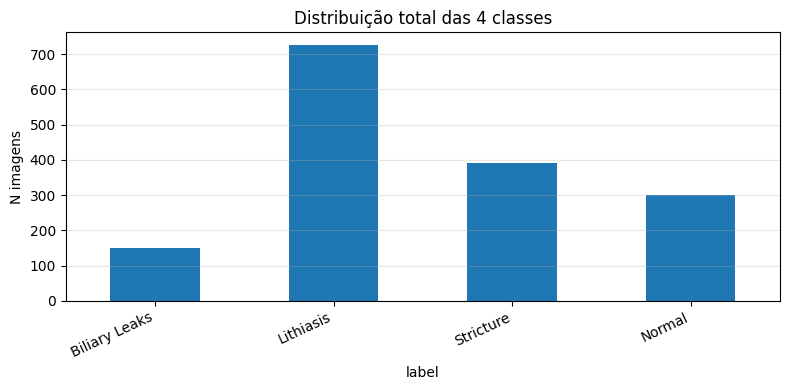

label,Biliary Leaks,Lithiasis,Stricture,Normal
split,,,,
test,17,123,84,43
train,110,505,255,197
val,24,98,53,59


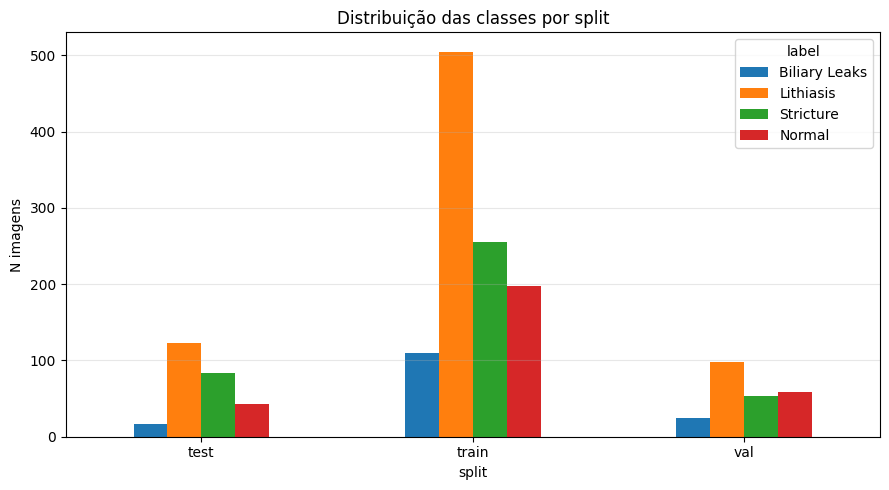

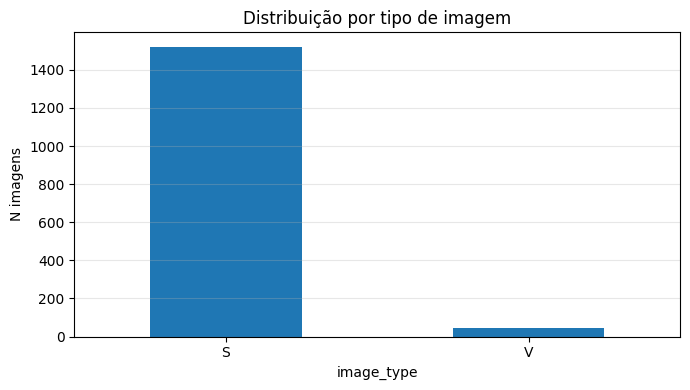

image_type,S,V
label,,
Biliary Leaks,146,5
Lithiasis,712,14
Normal,276,23
Stricture,387,5


In [6]:
# =========================
# 6. EDA — distribuição das classes por split
# =========================

df = pd.concat([
    train_df.assign(split='train'),
    val_df.assign(split='val'),
    test_df.assign(split='test')
], ignore_index=True)

plt.figure(figsize=(8, 4))
df['label'].value_counts().reindex(class_names, fill_value=0).plot(kind='bar')
plt.title('Distribuição total das 4 classes')
plt.ylabel('N imagens')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_class_distribution_total.png', dpi=300, bbox_inches='tight')
plt.show()

split_class_counts = pd.crosstab(df['split'], df['label']).reindex(columns=class_names, fill_value=0)
display(split_class_counts)
split_class_counts.to_csv(CSV_DIR / 'split_class_counts.csv')

split_class_counts.plot(kind='bar', figsize=(9, 5))
plt.title('Distribuição das classes por split')
plt.ylabel('N imagens')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_class_distribution_by_split.png', dpi=300, bbox_inches='tight')
plt.show()

if 'image_type' in df.columns:
    plt.figure(figsize=(7, 4))
    df['image_type'].value_counts().plot(kind='bar')
    plt.title('Distribuição por tipo de imagem')
    plt.ylabel('N imagens')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'eda_image_type_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

    display(pd.crosstab(df['label'], df['image_type']))


In [7]:
# =========================
# 7. Verificação dos splits carregados dos CSVs
# =========================

print('Split mode: manifests oficiais já existentes')

for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    n_patients = split_df['patient_id'].nunique() if 'patient_id' in split_df.columns else 'sem patient_id'
    print('\n', name.upper(), 'images:', len(split_df), 'patients:', n_patients)
    print(split_df['label'].value_counts().reindex(class_names, fill_value=0))

# Verificar leakage apenas se patient_id existir nos manifests
if all('patient_id' in x.columns for x in [train_df, val_df, test_df]):
    train_patients = set(train_df['patient_id'].astype(str))
    val_patients = set(val_df['patient_id'].astype(str))
    test_patients = set(test_df['patient_id'].astype(str))

    leak_train_val = len(train_patients & val_patients)
    leak_train_test = len(train_patients & test_patients)
    leak_val_test = len(val_patients & test_patients)

    print('\nVerificação de leakage por patient_id:')
    print('Interseção treino-val:', leak_train_val)
    print('Interseção treino-teste:', leak_train_test)
    print('Interseção val-teste:', leak_val_test)

    assert leak_train_val == 0, 'Leakage treino-val'
    assert leak_train_test == 0, 'Leakage treino-teste'
    assert leak_val_test == 0, 'Leakage val-teste'
else:
    print('\nAtenção: os manifests não têm patient_id em todos os splits; não foi possível verificar leakage por paciente.')

split_summary = pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'n_images': [len(train_df), len(val_df), len(test_df)],
    'n_patients': [
        train_df['patient_id'].nunique() if 'patient_id' in train_df.columns else np.nan,
        val_df['patient_id'].nunique() if 'patient_id' in val_df.columns else np.nan,
        test_df['patient_id'].nunique() if 'patient_id' in test_df.columns else np.nan,
    ]
})
display(split_summary)
split_summary.to_csv(CSV_DIR / 'split_summary_from_manifests.csv', index=False)


Split mode: manifests oficiais já existentes

 TRAIN images: 1067 patients: 305
label
Biliary Leaks    110
Lithiasis        505
Stricture        255
Normal           197
Name: count, dtype: int64

 VAL images: 234 patients: 65
label
Biliary Leaks    24
Lithiasis        98
Stricture        53
Normal           59
Name: count, dtype: int64

 TEST images: 267 patients: 66
label
Biliary Leaks     17
Lithiasis        123
Stricture         84
Normal            43
Name: count, dtype: int64

Verificação de leakage por patient_id:
Interseção treino-val: 0
Interseção treino-teste: 0
Interseção val-teste: 0


,split,n_images,n_patients
0,train,1067,305
1,val,234,65
2,test,267,66


In [8]:
# =========================
# 9. Dataset e transformações
# =========================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

plain_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

class ERCPDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = int(row["label_idx"])
        return img, label

train_dataset = ERCPDataset(train_df, transform=train_transform)
val_dataset = ERCPDataset(val_df, transform=eval_transform)
test_dataset = ERCPDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 134
Val batches: 30
Test batches: 34


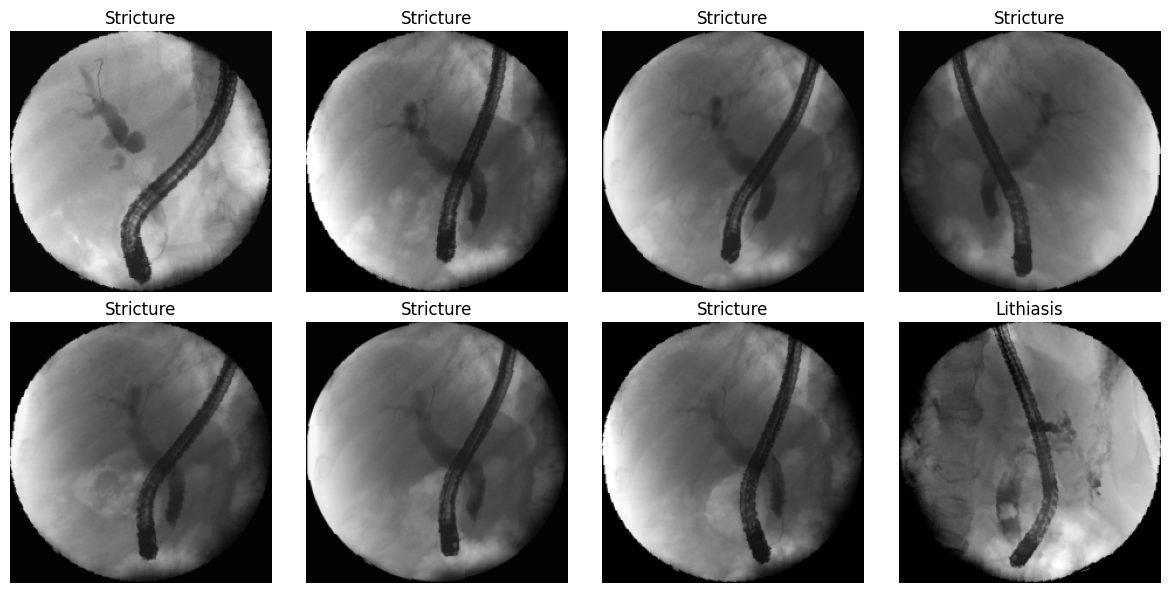

In [9]:
# =========================
# 10. Visualizar amostras
# =========================

def denormalize_tensor(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    x = t.cpu() * std + mean
    return x.clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for i in range(min(8, len(train_dataset))):
    img, label = train_dataset[i]
    img_show = denormalize_tensor(img).permute(1, 2, 0).numpy()
    axes[i].imshow(img_show, cmap="gray")
    axes[i].set_title(class_names[label])
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "train_samples.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# =========================
# 11. CrossEntropyLoss ponderada com pesos suavizados
# =========================

class_counts = train_df["label_idx"].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=0)
raw_weights = len(train_df) / (NUM_CLASSES * class_counts.replace(0, np.nan))
raw_weights = raw_weights.fillna(0).values.astype(np.float32)

# Suavização para evitar pesos demasiado extremos
smooth_weights = np.sqrt(raw_weights)
smooth_weights = smooth_weights / smooth_weights.mean()

class_weights = torch.tensor(smooth_weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts.to_dict())
print("Raw weights:", raw_weights)
print("Smooth weights:", smooth_weights)

# Sem CrossEntropyLoss ponderada: usamos CrossEntropyLoss ponderada para continuar a lidar
# com o desbalanceamento das classes, mas sem o termo crossentropy gamma.
criterion = nn.CrossEntropyLoss(weight=class_weights)


Class counts: {0: 110, 1: 505, 2: 255, 3: 197}
Raw weights: [2.425     0.5282178 1.0460784 1.3540609]
Smooth weights: [1.3933645 0.6503025 0.9151474 1.0411853]


In [11]:
# =========================
# 12. Criar modelo EfficientNetV2-S
# =========================

def create_model(num_classes=4):
    weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
    model = models.efficientnet_v2_s(weights=weights)

    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.35),
        nn.Linear(in_features, num_classes)
    )

    return model

model = create_model(NUM_CLASSES).to(device)
print(model.classifier)

def set_backbone_trainable(model, trainable=False):
    for param in model.features.parameters():
        param.requires_grad = trainable

def set_last_blocks_trainable(model, n_blocks=3):
    for param in model.features.parameters():
        param.requires_grad = False

    for block in model.features[-n_blocks:]:
        for param in block.parameters():
            param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

# Fase inicial: treinar só a cabeça
set_backbone_trainable(model, trainable=False)
for param in model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parâmetros treináveis: {trainable:,} / {total:,}")

Sequential(
  (0): Dropout(p=0.35, inplace=False)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)
Parâmetros treináveis: 5,124 / 20,182,612


In [12]:
# =========================
# 13. Funções de treino e avaliação
# =========================

scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def compute_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    if y_prob is not None:
        y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
        try:
            metrics["roc_auc_macro_ovr"] = roc_auc_score(
                y_true_bin, y_prob, average="macro", multi_class="ovr"
            )
        except Exception:
            metrics["roc_auc_macro_ovr"] = np.nan

        try:
            metrics["pr_auc_macro"] = average_precision_score(
                y_true_bin, y_prob, average="macro"
            )
        except Exception:
            metrics["pr_auc_macro"] = np.nan

    return metrics

def evaluate(model, loader):
    model.eval()

    all_true = []
    all_pred = []
    all_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
            all_prob.extend(probs.cpu().numpy())

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)
    all_prob = np.array(all_prob)

    metrics = compute_metrics(all_true, all_pred, all_prob)
    metrics["y_true"] = all_true
    metrics["y_pred"] = all_pred
    metrics["y_prob"] = all_prob

    return metrics

def train_one_epoch(model, loader, optimizer, criterion, accumulation_steps=1):
    model.train()

    running_loss = 0.0
    n_samples = 0

    optimizer.zero_grad(set_to_none=True)

    for step, (images, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(images)
            loss = criterion(logits, labels)
            loss_for_backward = loss / accumulation_steps

        scaler.scale(loss_for_backward).backward()

        if (step + 1) % accumulation_steps == 0 or (step + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    return running_loss / max(1, n_samples)

def run_training_phase(model, phase_name, epochs, optimizer, scheduler=None):
    history = []
    best_val_f1 = -1
    best_path = MODELS_DIR / f"best_{phase_name}.pt"
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            accumulation_steps=ACCUMULATION_STEPS
        )

        val_metrics = evaluate(model, val_loader)

        row = {
            "phase": phase_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "val_roc_auc_macro_ovr": val_metrics.get("roc_auc_macro_ovr", np.nan),
            "val_pr_auc_macro": val_metrics.get("pr_auc_macro", np.nan),
        }
        history.append(row)

        if scheduler is not None:
            scheduler.step(val_metrics["macro_f1"])

        print(
            f"[{phase_name}] Epoch {epoch:02d}/{epochs} | "
            f"loss={train_loss:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
            f"val_bal_acc={val_metrics['balanced_accuracy']:.4f} | "
            f"val_auc={val_metrics.get('roc_auc_macro_ovr', np.nan):.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:
            best_val_f1 = val_metrics["macro_f1"]
            patience_counter = 0
            torch.save(model.state_dict(), best_path)
            print("  -> novo melhor modelo guardado:", best_path)
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"Early stopping em {phase_name}.")
            break


    return history, best_path, best_val_f1

/tmp/ipykernel_1493827/908527125.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [13]:
# =========================
# 14. Fase 1 — treinar cabeça
# =========================

optimizer_head = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

scheduler_head = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_head,
    mode="max",
    factor=0.5,
    patience=2
)

hist_head, best_head_path, best_head_f1 = run_training_phase(
    model,
    phase_name="head",
    epochs=EPOCHS_HEAD,
    optimizer=optimizer_head,
    scheduler=scheduler_head
)

print("Melhor F1 validação fase head:", best_head_f1)

/tmp/ipykernel_1493827/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head] Epoch 01/8 | loss=1.3574 | val_macro_f1=0.2118 | val_bal_acc=0.2491 | val_auc=0.4956
  -> novo melhor modelo guardado: /mounts/mecd-ap-g5/models/efficientnetv2s_manifest_splits_crossentropy_no_focal/best_head.pt


/tmp/ipykernel_1493827/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head] Epoch 02/8 | loss=1.3261 | val_macro_f1=0.2411 | val_bal_acc=0.2618 | val_auc=0.4993
  -> novo melhor modelo guardado: /mounts/mecd-ap-g5/models/efficientnetv2s_manifest_splits_crossentropy_no_focal/best_head.pt


/tmp/ipykernel_1493827/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


...

[head] Epoch 06/8 | loss=1.2420 | val_macro_f1=0.2869 | val_bal_acc=0.2973 | val_auc=0.5218
  -> novo melhor modelo guardado: /mounts/mecd-ap-g5/models/efficientnetv2s_manifest_splits_crossentropy_no_focal/best_head.pt


/tmp/ipykernel_1493827/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head] Epoch 07/8 | loss=1.2371 | val_macro_f1=0.2803 | val_bal_acc=0.2882 | val_auc=0.5279


/tmp/ipykernel_1493827/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[head] Epoch 08/8 | loss=1.2124 | val_macro_f1=0.2585 | val_bal_acc=0.2653 | val_auc=0.5181
Melhor F1 validação fase head: 0.28694131955001523


In [14]:
# =========================
# 15. Fase 2 — fine-tuning parcial
# =========================

# Carregar melhor modelo da fase head
model.load_state_dict(torch.load(best_head_path, map_location=device))

# Descongelar apenas os últimos blocos do backbone
set_last_blocks_trainable(model, n_blocks=3)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parâmetros treináveis após fine-tuning parcial: {trainable:,} / {total:,}")

optimizer_ft = torch.optim.AdamW([
    {"params": model.features[-3:].parameters(), "lr": LR_BACKBONE},
    {"params": model.classifier.parameters(), "lr": LR_HEAD * 0.5},
], weight_decay=WEIGHT_DECAY)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode="max",
    factor=0.5,
    patience=2
)

hist_ft, best_ft_path, best_ft_f1 = run_training_phase(
    model,
    phase_name="finetune",
    epochs=EPOCHS_FINETUNE,
    optimizer=optimizer_ft,
    scheduler=scheduler_ft
)

print("Melhor F1 validação fine-tuning:", best_ft_f1)

Parâmetros treináveis após fine-tuning parcial: 18,361,036 / 20,182,612


/tmp/ipykernel_1493827/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune] Epoch 01/20 | loss=1.2020 | val_macro_f1=0.2260 | val_bal_acc=0.2284 | val_auc=0.5056
  -> novo melhor modelo guardado: /mounts/mecd-ap-g5/models/efficientnetv2s_manifest_splits_crossentropy_no_focal/best_finetune.pt


/tmp/ipykernel_1493827/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune] Epoch 02/20 | loss=1.1680 | val_macro_f1=0.2611 | val_bal_acc=0.2541 | val_auc=0.5192
  -> novo melhor modelo guardado: /mounts/mecd-ap-g5/models/efficientnetv2s_manifest_splits_crossentropy_no_focal/best_finetune.pt


...

[finetune] Epoch 17/20 | loss=0.6277 | val_macro_f1=0.3355 | val_bal_acc=0.3336 | val_auc=0.6290


/tmp/ipykernel_1493827/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune] Epoch 18/20 | loss=0.5934 | val_macro_f1=0.3249 | val_bal_acc=0.3256 | val_auc=0.6320


/tmp/ipykernel_1493827/908527125.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[finetune] Epoch 19/20 | loss=0.5702 | val_macro_f1=0.3205 | val_bal_acc=0.3269 | val_auc=0.6310
Early stopping em finetune.
Melhor F1 validação fine-tuning: 0.34291451434215614


In [15]:
# =========================
# 16. Escolher melhor modelo global
# =========================

if best_ft_f1 >= best_head_f1:
    best_model_path = best_ft_path
    best_phase = "finetune"
    best_val_f1 = best_ft_f1
else:
    best_model_path = best_head_path
    best_phase = "head"
    best_val_f1 = best_head_f1

model.load_state_dict(torch.load(best_model_path, map_location=device))
model = model.to(device)

print("Melhor fase:", best_phase)
print("Melhor Val Macro F1:", best_val_f1)
print("Modelo:", best_model_path)

torch.save(model.state_dict(), MODELS_DIR / "best_model_global.pt")

Melhor fase: finetune
Melhor Val Macro F1: 0.34291451434215614
Modelo: /mounts/mecd-ap-g5/models/efficientnetv2s_manifest_splits_crossentropy_no_focal/best_finetune.pt


,phase,epoch,train_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_roc_auc_macro_ovr,val_pr_auc_macro,global_epoch
22,finetune,15,0.672965,0.367521,0.317541,0.310786,0.370571,0.621521,0.371586,23
23,finetune,16,0.631728,0.371795,0.317926,0.312994,0.373722,0.629575,0.375779,24
24,finetune,17,0.627680,0.384615,0.333606,0.335497,0.395577,0.629025,0.378514,25
25,finetune,18,0.593406,0.384615,0.325579,0.324911,0.390814,0.631989,0.384088,26
26,finetune,19,0.570232,0.380342,0.326880,0.320464,0.380453,0.631037,0.384706,27


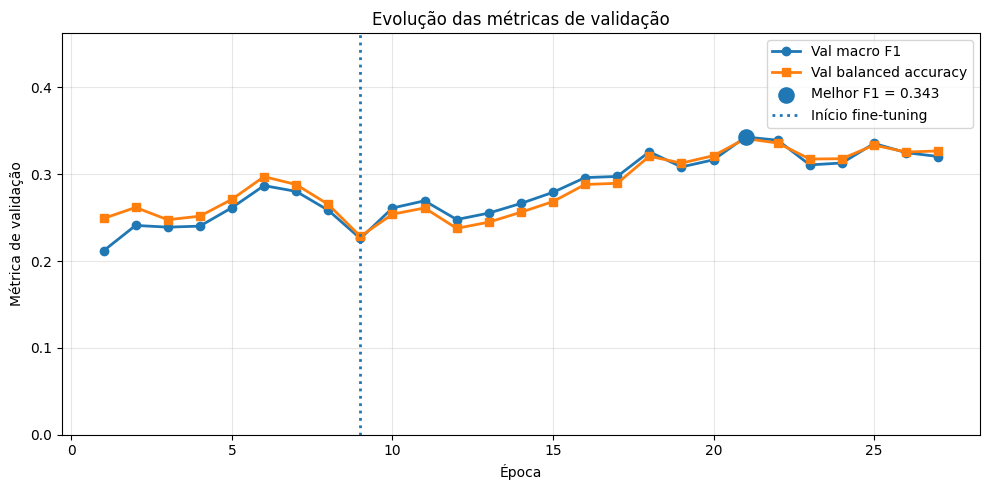

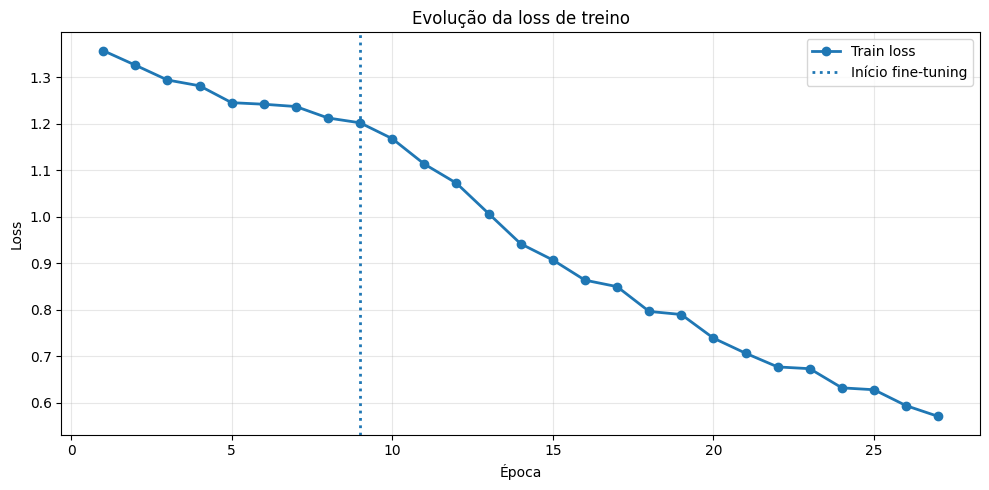

In [16]:
# =========================
# 17. Curvas de treino
# =========================

hist_df = pd.concat([pd.DataFrame(hist_head), pd.DataFrame(hist_ft)], ignore_index=True)
hist_df["global_epoch"] = np.arange(1, len(hist_df) + 1)

hist_df.to_csv(CSV_DIR / "training_history.csv", index=False)
display(hist_df.tail())

phase_change_epoch = None
if hist_df["phase"].nunique() > 1:
    first_phase = hist_df["phase"].iloc[0]
    change_rows = hist_df[hist_df["phase"] != first_phase]
    if len(change_rows) > 0:
        phase_change_epoch = int(change_rows["global_epoch"].iloc[0])

best_idx = hist_df["val_macro_f1"].idxmax()
best_epoch = int(hist_df.loc[best_idx, "global_epoch"])
best_f1 = float(hist_df.loc[best_idx, "val_macro_f1"])

# Gráfico zoomado sem baseline
plt.figure(figsize=(10, 5))
plt.plot(hist_df["global_epoch"], hist_df["val_macro_f1"], marker="o", linewidth=2, label="Val macro F1")
plt.plot(hist_df["global_epoch"], hist_df["val_balanced_accuracy"], marker="s", linewidth=2, label="Val balanced accuracy")
plt.scatter(best_epoch, best_f1, s=120, zorder=5, label=f"Melhor F1 = {best_f1:.3f}")

if phase_change_epoch is not None:
    plt.axvline(phase_change_epoch, linestyle=":", linewidth=2, label="Início fine-tuning")

plt.xlabel("Época")
plt.ylabel("Métrica de validação")
plt.title("Evolução das métricas de validação")
plt.ylim(0, min(1.0, max(hist_df["val_macro_f1"].max(), hist_df["val_balanced_accuracy"].max()) + 0.12))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_metrics_zoomed.png", dpi=300, bbox_inches="tight")
plt.show()

# Loss
plt.figure(figsize=(10, 5))
plt.plot(hist_df["global_epoch"], hist_df["train_loss"], marker="o", linewidth=2, label="Train loss")
if phase_change_epoch is not None:
    plt.axvline(phase_change_epoch, linestyle=":", linewidth=2, label="Início fine-tuning")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Evolução da loss de treino")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "training_loss.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# =========================
# 18. Avaliação no teste
# =========================

test_metrics = evaluate(model, test_loader)

print("TEST METRICS")
print("Accuracy:", test_metrics["accuracy"])
print("Balanced accuracy:", test_metrics["balanced_accuracy"])
print("Macro F1:", test_metrics["macro_f1"])
print("Weighted F1:", test_metrics["weighted_f1"])
print("ROC-AUC macro OvR:", test_metrics.get("roc_auc_macro_ovr", np.nan))
print("PR-AUC macro:", test_metrics.get("pr_auc_macro", np.nan))

print("\nClassification report:")
report_txt = classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    target_names=class_names,
    zero_division=0
)
print(report_txt)

report_dict = classification_report(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report_dict).T.to_csv(CSV_DIR / "classification_report_test.csv")

summary = {
    "split_mode": "StratifiedGroupKFold_patient_id_no_leakage",
    "model": "EfficientNetV2-S",
    "loss": "WeightedCrossEntropyLoss",
    "baseline_macro_f1": BASELINE_MACRO_F1,
    "best_val_macro_f1": float(best_val_f1),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_balanced_accuracy": float(test_metrics["balanced_accuracy"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "test_weighted_f1": float(test_metrics["weighted_f1"]),
    "test_roc_auc_macro_ovr": float(test_metrics.get("roc_auc_macro_ovr", np.nan)),
    "test_pr_auc_macro": float(test_metrics.get("pr_auc_macro", np.nan)),
    "difference_to_baseline": float(test_metrics["macro_f1"] - BASELINE_MACRO_F1),
    "train_patients": int(train_df["patient_id"].nunique()),
    "val_patients": int(val_df["patient_id"].nunique()),
    "test_patients": int(test_df["patient_id"].nunique()),
    "leak_train_val": int(leak_train_val),
    "leak_train_test": int(leak_train_test),
    "leak_val_test": int(leak_val_test),
}

with open(RESULTS_DIR / "test_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4, ensure_ascii=False)

pd.DataFrame([summary]).to_csv(CSV_DIR / "test_summary.csv", index=False)
summary

TEST METRICS
Accuracy: 0.4681647940074906
Balanced accuracy: 0.36294817132752144
Macro F1: 0.36252723778496976
Weighted F1: 0.44999101338728353
ROC-AUC macro OvR: 0.6510108710943492
PR-AUC macro: 0.386087870495051

Classification report:
               precision    recall  f1-score   support

Biliary Leaks       0.14      0.18      0.15        17
    Lithiasis       0.51      0.70      0.59       123
    Stricture       0.50      0.27      0.35        84
       Normal       0.42      0.30      0.35        43

     accuracy                           0.47       267
    macro avg       0.39      0.36      0.36       267
 weighted avg       0.47      0.47      0.45       267



{'split_mode': 'StratifiedGroupKFold_patient_id_no_leakage',
 'model': 'EfficientNetV2-S',
 'loss': 'WeightedCrossEntropyLoss',
 'baseline_macro_f1': 0.738,
 'best_val_macro_f1': 0.34291451434215614,
 'test_accuracy': 0.4681647940074906,
 'test_balanced_accuracy': 0.36294817132752144,
 'test_macro_f1': 0.36252723778496976,
 'test_weighted_f1': 0.44999101338728353,
 'test_roc_auc_macro_ovr': 0.6510108710943492,
 'test_pr_auc_macro': 0.386087870495051,
 'difference_to_baseline': -0.37547276221503023,
 'train_patients': 305,
 'val_patients': 65,
 'test_patients': 66,
 'leak_train_val': 0,
 'leak_train_test': 0,
 'leak_val_test': 0}

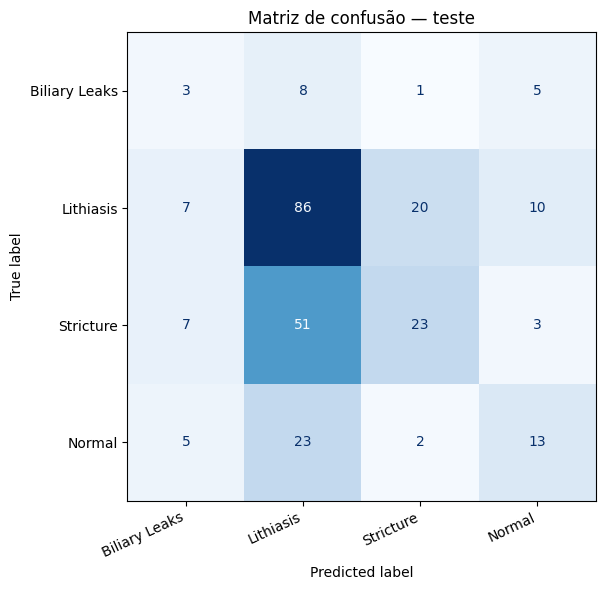

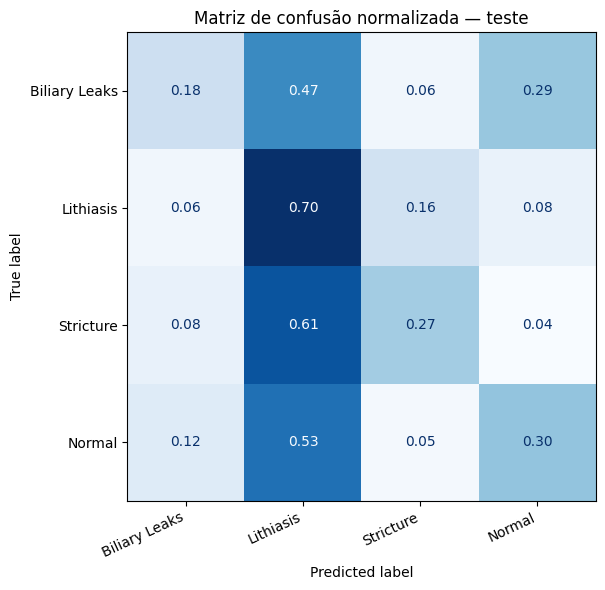

In [18]:
# =========================
# 19. Matriz de confusão
# =========================

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"], labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Matriz de confusão — teste")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_test.png", dpi=300, bbox_inches="tight")
plt.show()

# Matriz normalizada
cm_norm = confusion_matrix(
    test_metrics["y_true"],
    test_metrics["y_pred"],
    labels=list(range(NUM_CLASSES)),
    normalize="true"
)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
plt.title("Matriz de confusão normalizada — teste")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_test_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

Baseline macro F1: 0.738
Macro F1 teste: 0.36252723778496976
Diferença: -0.37547276221503023


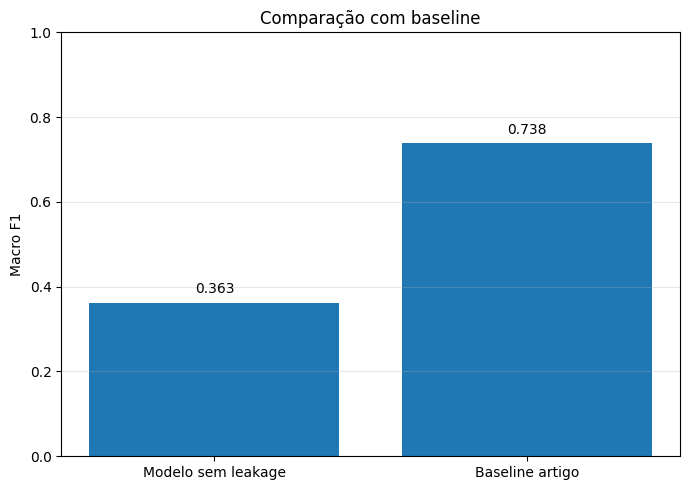

In [19]:
# =========================
# 20. Comparação com baseline
# =========================

test_macro_f1 = test_metrics["macro_f1"]
diff = test_macro_f1 - BASELINE_MACRO_F1

print("Baseline macro F1:", BASELINE_MACRO_F1)
print("Macro F1 teste:", test_macro_f1)
print("Diferença:", diff)

plt.figure(figsize=(7, 5))
labels = ["Modelo sem leakage", "Baseline artigo"]
values = [test_macro_f1, BASELINE_MACRO_F1]
bars = plt.bar(labels, values)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.ylabel("Macro F1")
plt.title("Comparação com baseline")
plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "macro_f1_vs_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# =========================
# 21. Avaliação opcional com TTA no teste
# =========================

def tta_predict_one(model, image_tensor):
    model.eval()

    # image_tensor está normalizado com shape C,H,W
    variants = [
        image_tensor,
        torch.flip(image_tensor, dims=[2]),  # flip horizontal
    ]

    probs_all = []

    with torch.no_grad():
        for img in variants:
            x = img.unsqueeze(0).to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            probs_all.append(probs.cpu())

    probs_mean = torch.mean(torch.stack(probs_all), dim=0)
    return probs_mean.squeeze(0).numpy()

def evaluate_tta(model, dataset):
    y_true = []
    y_prob = []

    for i in range(len(dataset)):
        img, label = dataset[i]
        probs = tta_predict_one(model, img)
        y_true.append(label)
        y_prob.append(probs)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = y_prob.argmax(axis=1)

    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["y_true"] = y_true
    metrics["y_pred"] = y_pred
    metrics["y_prob"] = y_prob

    return metrics

test_tta_metrics = evaluate_tta(model, test_dataset)

print("TEST METRICS COM TTA")
print("Accuracy:", test_tta_metrics["accuracy"])
print("Balanced accuracy:", test_tta_metrics["balanced_accuracy"])
print("Macro F1:", test_tta_metrics["macro_f1"])
print("Weighted F1:", test_tta_metrics["weighted_f1"])
print("ROC-AUC macro OvR:", test_tta_metrics.get("roc_auc_macro_ovr", np.nan))
print("PR-AUC macro:", test_tta_metrics.get("pr_auc_macro", np.nan))

pd.DataFrame([{
    "test_macro_f1_tta": test_tta_metrics["macro_f1"],
    "test_balanced_accuracy_tta": test_tta_metrics["balanced_accuracy"],
    "test_roc_auc_macro_ovr_tta": test_tta_metrics.get("roc_auc_macro_ovr", np.nan),
    "test_pr_auc_macro_tta": test_tta_metrics.get("pr_auc_macro", np.nan),
}]).to_csv(CSV_DIR / "test_tta_summary.csv", index=False)

TEST METRICS COM TTA
Accuracy: 0.5093632958801498
Balanced accuracy: 0.4182019801681308
Macro F1: 0.42061699329992014
Weighted F1: 0.49681823075081505
ROC-AUC macro OvR: 0.667662306214031
PR-AUC macro: 0.410684273274723


In [21]:
# =========================
# 22. Probabilidades exemplo
# =========================

probs_df = pd.DataFrame(test_metrics["y_prob"], columns=[f"prob_{c}" for c in class_names])
probs_df["true_idx"] = test_metrics["y_true"]
probs_df["pred_idx"] = test_metrics["y_pred"]
probs_df["true_label"] = [idx_to_class[i] for i in test_metrics["y_true"]]
probs_df["pred_label"] = [idx_to_class[i] for i in test_metrics["y_pred"]]
probs_df["image_path"] = test_df.reset_index(drop=True)["image_path"].values

probs_df.to_csv(CSV_DIR / "test_probabilities.csv", index=False)
display(probs_df.head())

,prob_Biliary Leaks,prob_Lithiasis,prob_Stricture,prob_Normal,true_idx,pred_idx,true_label,pred_label,image_path
0,0.749450,0.135799,0.013300,0.101451,3,0,Normal,Biliary Leaks,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
1,0.506590,0.149129,0.273455,0.070825,1,0,Lithiasis,Biliary Leaks,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
2,0.010717,0.606497,0.264921,0.117865,1,1,Lithiasis,Lithiasis,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
3,0.044908,0.386962,0.390175,0.177955,1,2,Lithiasis,Stricture,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...
4,0.058693,0.414304,0.440506,0.086496,1,2,Lithiasis,Stricture,/mounts/mecd-ap-g5/data/MIQR-CC-Dataset/proces...


,image_type,n,accuracy,balanced_accuracy,macro_f1
0,S,256,0.464844,0.344118,0.339621
1,V,11,0.545455,0.214286,0.200000


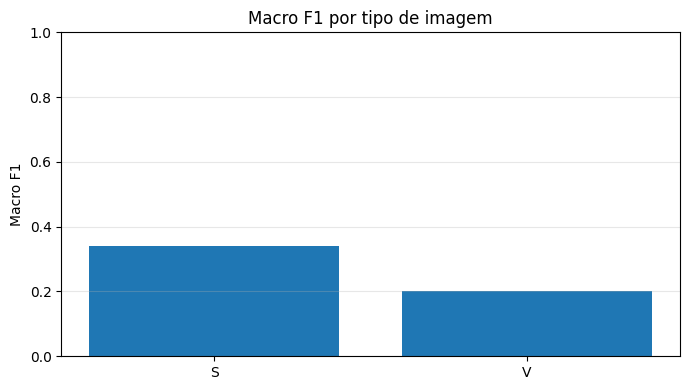

In [22]:
# =========================
# 23. Análise por image_type, se existir
# =========================

if "image_type" in test_df.columns:
    type_df = test_df.reset_index(drop=True).copy()
    type_df["y_true"] = test_metrics["y_true"]
    type_df["y_pred"] = test_metrics["y_pred"]

    rows = []
    for img_type, g in type_df.groupby("image_type"):
        rows.append({
            "image_type": img_type,
            "n": len(g),
            "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
            "balanced_accuracy": balanced_accuracy_score(g["y_true"], g["y_pred"]),
            "macro_f1": f1_score(g["y_true"], g["y_pred"], average="macro", zero_division=0),
        })

    type_metrics_df = pd.DataFrame(rows)
    display(type_metrics_df)
    type_metrics_df.to_csv(CSV_DIR / "metrics_by_image_type.csv", index=False)

    plt.figure(figsize=(7, 4))
    plt.bar(type_metrics_df["image_type"], type_metrics_df["macro_f1"])
    plt.ylabel("Macro F1")
    plt.title("Macro F1 por tipo de imagem")
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "macro_f1_by_image_type.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Coluna image_type não existe no dataset.")

In [23]:
# =========================
# 24. Grad-CAM para EfficientNetV2-S
# =========================

# Desativar ReLU inplace para evitar problemas com hooks
def replace_inplace_relu(module):
    for name, child in module.named_children():
        if isinstance(child, nn.ReLU):
            setattr(module, name, nn.ReLU(inplace=False))
        else:
            replace_inplace_relu(child)

replace_inplace_relu(model)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = self.target_layer.register_forward_hook(self.save_activation)
        self.backward_handle = self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach().clone()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach().clone()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        logits = self.model(x)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        score = logits[:, class_idx].sum()
        score.backward(retain_graph=False)

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam.unsqueeze(1),
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False
        ).squeeze(1)

        cam = cam[0].detach().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, logits.detach()

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

# Camada alvo: último bloco de features
target_layer = model.features[-1]
gradcam = GradCAM(model, target_layer)

print("Grad-CAM preparado com target_layer = model.features[-1]")

Grad-CAM preparado com target_layer = model.features[-1]


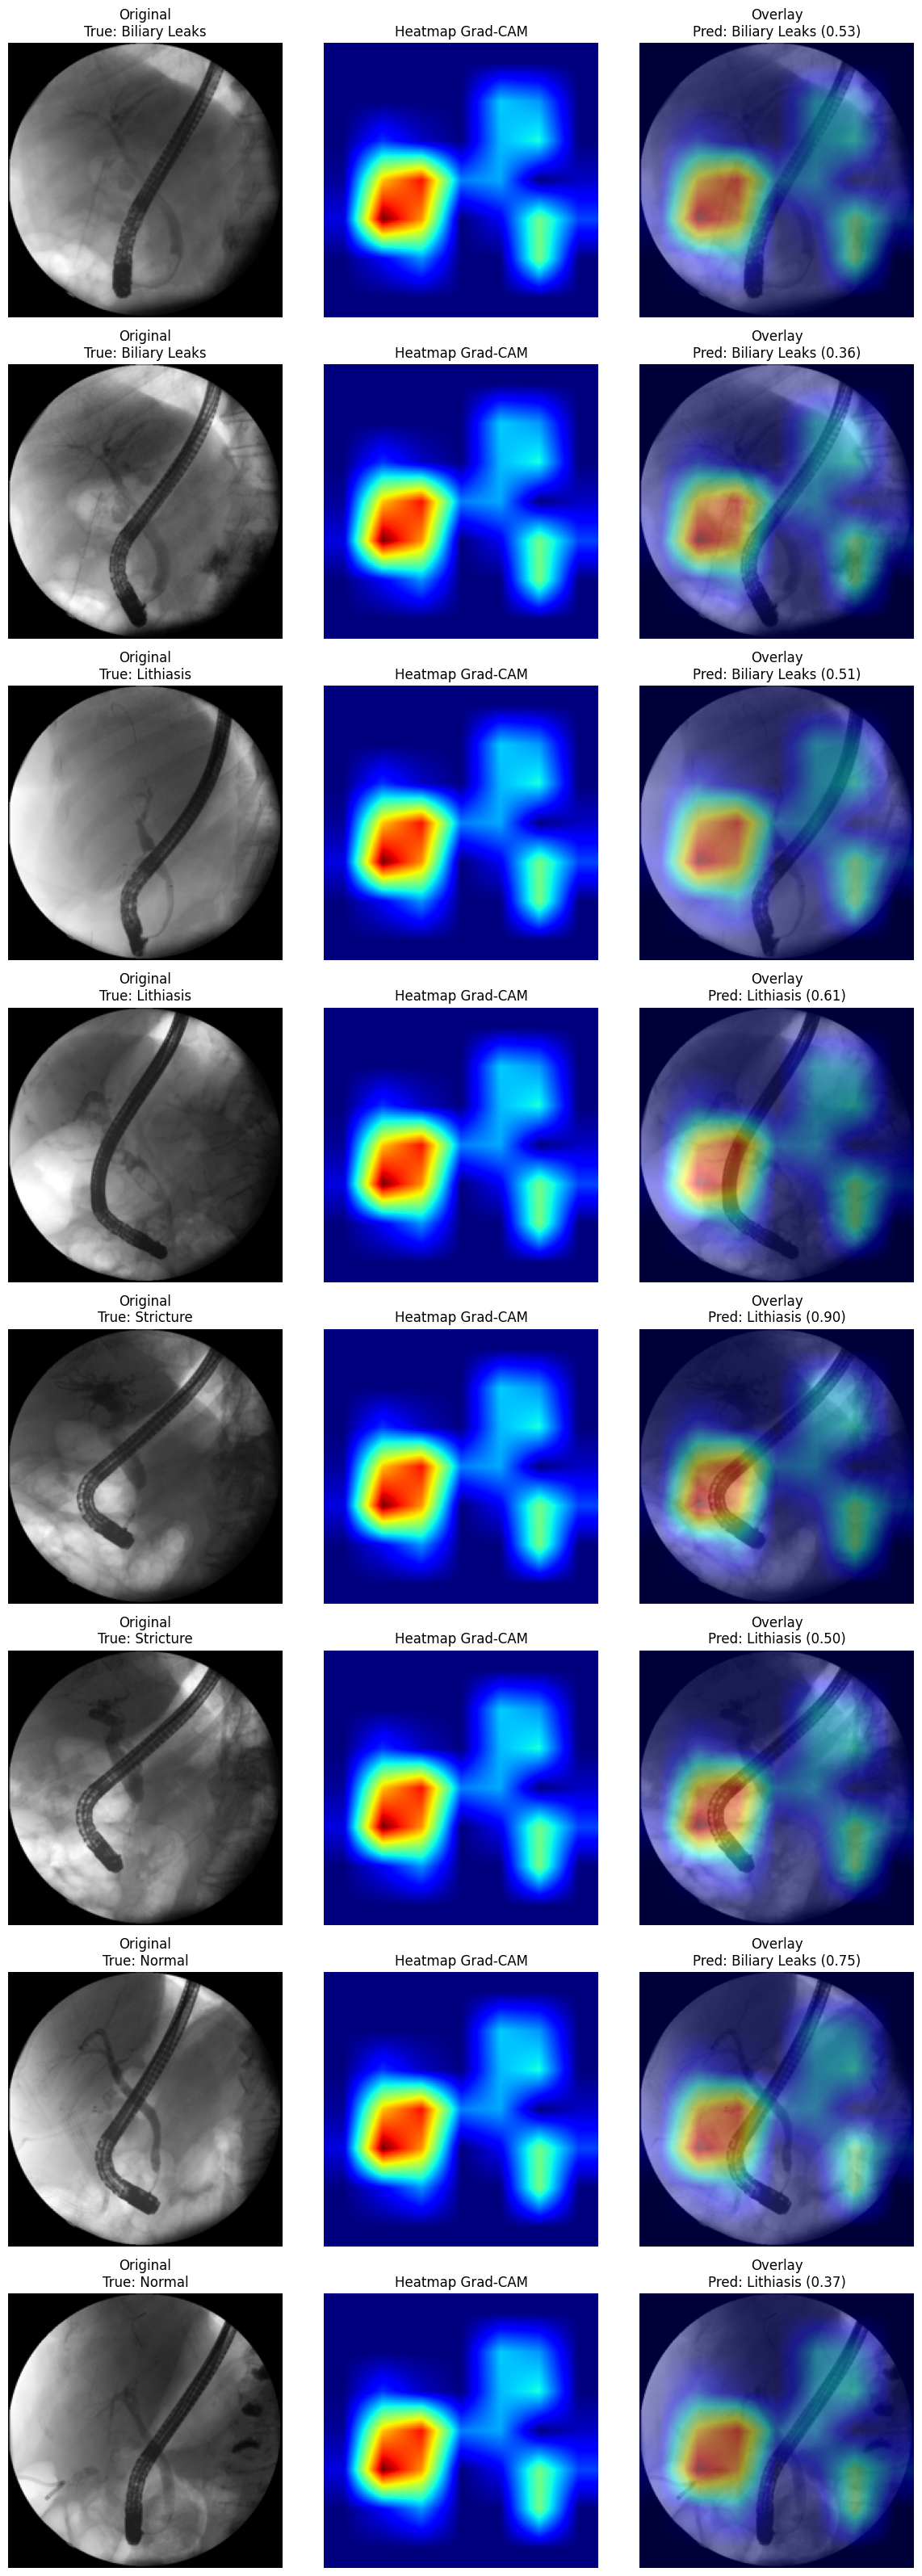

Grad-CAM guardado em: /mounts/mecd-ap-g5/results/efficientnetv2s_manifest_splits_crossentropy_no_focal/figures/gradcam_examples_by_class.png


In [25]:
# =========================
# 25. Mostrar exemplos Grad-CAM por classe
# =========================

def load_original_image_for_display(path):
    img = Image.open(path).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.array(img) / 255.0

def show_gradcam_examples(model, dataset, dataframe, n_per_class=2):
    model.eval()

    selected_indices = []

    df_reset = dataframe.reset_index(drop=True)

    for class_idx in range(NUM_CLASSES):
        class_indices = df_reset.index[df_reset["label_idx"] == class_idx].tolist()
        selected_indices.extend(class_indices[:n_per_class])

    n = len(selected_indices)
    if n == 0:
        print("Sem exemplos para Grad-CAM.")
        return

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_i, idx in enumerate(selected_indices):
        img_tensor, true_label = dataset[idx]
        x = img_tensor.unsqueeze(0).to(device)

        cam, logits = gradcam(x)
        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()[0]
        pred_label = int(np.argmax(probs))

        original = load_original_image_for_display(df_reset.iloc[idx]["image_path"])

        axes[row_i, 0].imshow(original)
        axes[row_i, 0].set_title(f"Original\nTrue: {class_names[true_label]}")
        axes[row_i, 0].axis("off")

        axes[row_i, 1].imshow(cam, cmap="jet")
        axes[row_i, 1].set_title("Heatmap Grad-CAM")
        axes[row_i, 1].axis("off")

        axes[row_i, 2].imshow(original)
        axes[row_i, 2].imshow(cam, cmap="jet", alpha=0.45)
        axes[row_i, 2].set_title(
            f"Overlay\nPred: {class_names[pred_label]} ({probs[pred_label]:.2f})"
        )
        axes[row_i, 2].axis("off")

    plt.tight_layout()
    out_path = FIGURES_DIR / "gradcam_examples_by_class.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Grad-CAM guardado em:", out_path)

show_gradcam_examples(model, test_dataset, test_df, n_per_class=2)
gradcam.close()

## Notas para o relatório

Pontos que este notebook cobre:

- Análise exploratória da distribuição das classes;
- utilização das imagens processadas;
- classificação multi-classe nas 4 classes do enunciado;
- junção de `Benign Stricture` e `Malignant Stricture` em `Stricture`;
- split treino/validação/teste sem sobreposição de `patient_id`;
- pré-processamento com resize e normalização ImageNet;
- augmentation moderada para robustez;
- balanceamento com CrossEntropyLoss ponderada e pesos suavizados;
- modelo EfficientNetV2-S com transfer learning;
- fine-tuning parcial;
- macro F1, weighted F1, balanced accuracy, AUC-ROC e PR-AUC;
- matriz de confusão;
- probabilidades por classe;
- comparação com baseline 0.738;
- Grad-CAM para interpretabilidade.